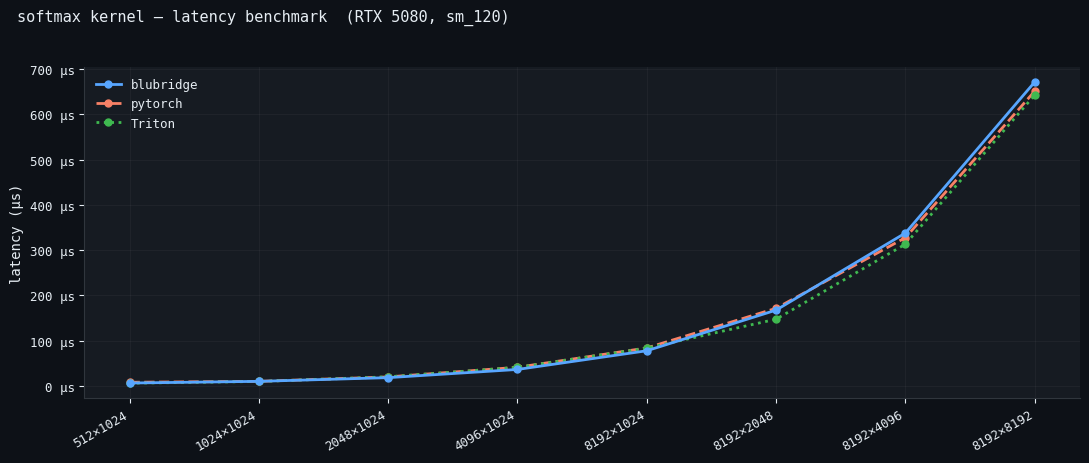

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ── Your benchmark data ───────────────────────────────────────────────────────
sizes = [
    '512×1024', '1024×1024', '2048×1024', '4096×1024',
    '8192×1024', '8192×2048', '8192×4096', '8192×8192'
]

blubridge  = [6.5,  10.2,  18.4,  36.5, 77.8, 167.6,  337.9,  671.6]
pytorch  = [8.2,  10.2,  20.0,  41.3, 84.0, 171.6,  327.7, 651.3]
triton = [6.1,  9.9,  20.2,  41.0, 83.6, 147.5,  313.3,  642.8]

# ── Colors ────────────────────────────────────────────────────────────────────
BG      = '#0d1117'
PANEL   = '#161b22'
GRID_C  = '#ffffff'
TEXT    = '#e6edf3'
BLUE    = '#58a6ff'
ORANGE  = '#f78166'
GREEN   = '#3fb950'

plt.rcParams.update({
    'font.family':        'monospace',
    'text.color':         TEXT,
    'axes.labelcolor':    TEXT,
    'xtick.color':        TEXT,
    'ytick.color':        TEXT,
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.spines.left':   True,
    'axes.spines.bottom': True,
    'axes.edgecolor':     '#30363d',
    'axes.grid':          True,
    'grid.color':         GRID_C,
    'grid.alpha':         0.06,
    'grid.linestyle':     '-',
    'grid.linewidth':     0.5,
    'figure.facecolor':   BG,
    'axes.facecolor':     PANEL,
})

x = np.arange(len(sizes))

# ── Figure ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 4.5))

ax.plot(x, blubridge, color=BLUE,   linewidth=2, marker='o', markersize=5,
        label='blubridge', zorder=3)
ax.plot(x, pytorch,   color=ORANGE, linewidth=2, marker='o', markersize=5,
        linestyle='--', label='pytorch', zorder=2)
ax.plot(x, triton, color=GREEN,  linewidth=2, marker='o', markersize=5,
        linestyle=':', label='Triton', zorder=2)

ax.set_xticks(x)
ax.set_xticklabels(sizes, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('latency (µs)', fontsize=10)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f'{int(v)} µs'))
ax.legend(fontsize=9, framealpha=0, loc='upper left',
          labelcolor=TEXT)
ax.tick_params(labelsize=9)

fig.suptitle('softmax kernel — latency benchmark  (RTX 5080, sm_120)',
             fontsize=11, fontweight='normal', y=1.02, x=0.02, ha='left',
             color=TEXT)

plt.tight_layout()
plt.savefig('benchmark.png', dpi=180, bbox_inches='tight', facecolor=BG)
plt.show()

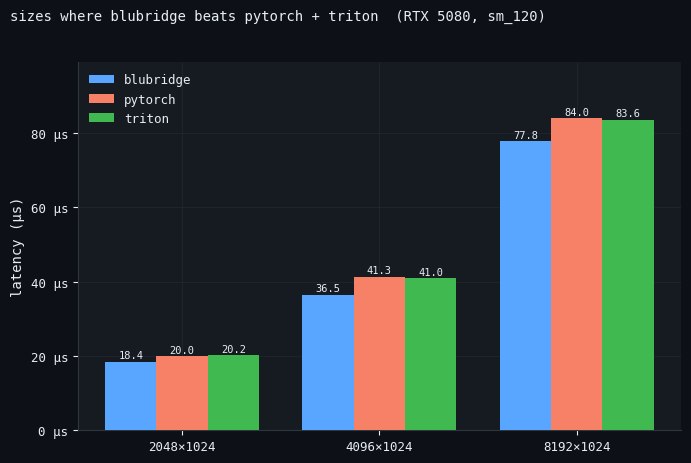

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ── Data (copied from cell above) ────────────────────────────────────────────
sizes      = ['512×1024','1024×1024','2048×1024','4096×1024','8192×1024','8192×2048','8192×4096','8192×8192']
blubridge  = [6.5,  10.2,  18.4,  36.5, 77.8, 167.6, 337.9, 671.6]
pytorch    = [8.2,  10.2,  20.0,  41.3, 84.0, 171.6, 327.7, 651.3]
triton     = [6.1,   9.9,  20.2,  41.0, 83.6, 147.5, 313.3, 642.8]

# ── Filter: only sizes where blubridge beats BOTH pytorch and triton ──────────
win_idx   = [i for i in range(len(sizes)) if blubridge[i] < pytorch[i] and blubridge[i] < triton[i]]
win_sizes = [sizes[i]     for i in win_idx]
bb_vals   = [blubridge[i] for i in win_idx]
pt_vals   = [pytorch[i]   for i in win_idx]
tr_vals   = [triton[i]    for i in win_idx]

# ── Dark theme ────────────────────────────────────────────────────────────────
BG     = '#0d1117'
PANEL  = '#161b22'
TEXT   = '#e6edf3'
BLUE   = '#58a6ff'
ORANGE = '#f78166'
GREEN  = '#3fb950'

plt.rcParams.update({
    'font.family':        'monospace',
    'text.color':         TEXT,
    'axes.labelcolor':    TEXT,
    'xtick.color':        TEXT,
    'ytick.color':        TEXT,
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.spines.left':   True,
    'axes.spines.bottom': True,
    'axes.edgecolor':     '#30363d',
    'axes.grid':          True,
    'grid.color':         '#ffffff',
    'grid.alpha':         0.06,
    'grid.linestyle':     '-',
    'grid.linewidth':     0.5,
    'figure.facecolor':   BG,
    'axes.facecolor':     PANEL,
})

n      = len(win_sizes)
x      = np.arange(n)
width  = 0.26

fig, ax = plt.subplots(figsize=(7, 4.5))

b1 = ax.bar(x - width, bb_vals, width, label='blubridge', color=BLUE,   zorder=3)
b2 = ax.bar(x,         pt_vals, width, label='pytorch',   color=ORANGE, zorder=3)
b3 = ax.bar(x + width, tr_vals, width, label='triton',    color=GREEN,  zorder=3)

# Value labels on top of each bar
for bars in (b1, b2, b3):
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.4,
            f'{bar.get_height():.1f}',
            ha='center', va='bottom', fontsize=7.5, color=TEXT
        )

ax.set_xticks(x)
ax.set_xticklabels(win_sizes, fontsize=9)
ax.set_ylabel('latency (µs)', fontsize=10)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f'{int(v)} µs'))
ax.legend(fontsize=9, framealpha=0, labelcolor=TEXT)
ax.tick_params(labelsize=9)
ax.set_ylim(0, max(pt_vals + tr_vals) * 1.18)

fig.suptitle('sizes where blubridge beats pytorch + triton  (RTX 5080, sm_120)',
             fontsize=10, fontweight='normal', y=1.02, x=0.02, ha='left', color=TEXT)

plt.tight_layout()
plt.savefig('benchmark_wins.png', dpi=180, bbox_inches='tight', facecolor=BG)
plt.show()
